# Demo: `cgi_noise` vs. EETC-augmented integration time calculators

This notebook compares the original (`cgi_noise` only) and EETC-augmented
integration time calculators in `corgietc`, reproducing two of the plot
styles from `01_Anatomy_of_an_Integration_Time_Calculation.ipynb`:

1. Integration time vs. target dMag, for a single star.
2. Integration time vs. target V mag, for a synthetic multi-star
   `TargetList` (a "scatter plot of individual targets").

It compares:

- `calc_intTime` -- the unmodified original, always `cgi_noise`-sourced.
- `calc_intTime_eetc` -- run with all three non-trivial combinations of
  `fluxModel`/`detectorModel` (`"cgi_noise"` or `"eetc"`).

**Important:** `fluxModel="eetc"` requires `mode["eetc_search"]` (or
`mode["eetc_sequence_name"]`) to be set, so EETC knows which sequence to use
for the unocculted reference-star flux. The `EETC_SEARCH` dict below is a
placeholder copied from the EETC tutorial notebook's example (HLC band 1
imaging) -- replace it with the values that actually match the mode you're
using (`corgietc_instance.search_eetc_sequences(...)` can help find them).

**Note:** this notebook depends on the same environment as the tutorial
notebooks (`corgietc`, `cgi_noise`, `EXOSIMS`, `eetc` all installed, with
`CORGIETC_DATA_DIR`/`CGI_NOISE_DATA_DIR` set). It has not been executed in
the session that generated it -- please run it locally and flag anything
that needs adjusting. See `EETC_INTEGRATION_NOTES.md` for the full list of
caveats behind the `_eetc` functions used here.

# Notes on the details of EETC implementation



New lines of code are presented below
- lines 311, 312 -> self.
- lines 26 - 62 -> initialize eetc
- lines 64 - 124 -> rough_wall_clock function
- lines 126 - 144 -> _parse_spt function
- lines 146 - 178 -> match_spt_to_eetc_grid function
- lines 614 - 677 -> _get_eetc_sequance_name function
- lines 679 - 699 -> search_eetc_sequences function
- lines 701 - 767 -> _get_eetc_star_flux function
- lines 1077 - 1478 -> Cp_Cb_Csp_eetc function
- lines 1481 - 1565 -> compute_frame_time_and_dqe_eetc function
- lines 1567 - 1623 -> deector_noise_rates_eetc function
- lines 1734 - 1843 -> calc_intTime_eetc function

Explanation of the implementations

calc_intTime function utilizes another original corgietc function, Cp_Cb_Csp which then calls compute_frametime_and_dqe.
In calc_intTime_eetc those are replaced with Cp_Cb_Csp_eetc and compute_frametime_and_dqe_eetc. 

Details about the implementation of the new functions

Cp_Cb_Csp_eetc 
- "eetc" version of the function has its QE_img set to 1 (since eetc already account for the QE in flux calculations)
- flux is calculated using the eetc flux model instead of the original version (_get_eetc_star_flux function)

compute_frame_time_and_dqe_eetc
- this function uses excam config information from EETC (from eetc_excam_config file), values such as EM gain, readoff noise, dQE, etc

detector_noise_rates_eetc
- this function, much rather the previous one, loads the detector data from eetc config files, such as darke, CIC, etc

both compute_frame_time_and_dqe_eetc and detector_noise_rates_eetc are then used in Cp_Cb_Csp_eetc function, which in combination with using EETC flux composes the eetc version of the Cp_Cb_Csp_eetc function. 

functions such as search_eetc_sequences, _get_eetc_sequance_name, match_spt_to_eetc_grid come together to derive and pass through an appropirate sequence name for eetc calculations. 

All those components come together into calc_intTime_eetc function. Two main implementations can be categorized as either flux change or detector change. Thus, tthe functions allow an input to change either, or both of those components into their eetc equivalents. 

<style>
.eetc-table { width: 100%; table-layout: fixed; border-collapse: collapse; font-size: 0.85em; }
.eetc-table th, .eetc-table td { border: 1px solid #ccc; padding: 6px; vertical-align: top; word-wrap: break-word; overflow-wrap: break-word; }
.eetc-table th:nth-child(1), .eetc-table td:nth-child(1) { width: 4%; }
.eetc-table th:nth-child(2), .eetc-table td:nth-child(2) { width: 24%; }
.eetc-table th:nth-child(3), .eetc-table td:nth-child(3) { width: 24%; }
.eetc-table th:nth-child(4), .eetc-table td:nth-child(4) { width: 48%; }
</style>

## EETC integration: what changed, call by call

<table class="eetc-table">
<tr><th>#</th><th>cgi_noise call (in <code>Cp_Cb_Csp</code>)</th><th>EETC replacement (in <code>Cp_Cb_Csp_eetc</code>)</th><th>Notes / caveats</th></tr>
<tr><td>1</td><td><code>TL.starFlux(sInds, mode)</code></td><td><code>self._get_eetc_star_flux(...)</code><br>(when <code>fluxModel="eetc"</code>)</td><td>Needs <code>mode["eetc_sequence_name"]</code> or <code>mode["eetc_search"]</code> -- no auto mapping from <code>mode["Scenario"]</code> to EETC's FPAM/CFAM/DPAM keys. Spectral types nearest-matched to EETC's grid via <code>match_spt_to_eetc_grid</code>; check <code>extra["eetc_matched_spt"]</code>.</td></tr>
<tr><td>2</td><td><code>starFlux</code>: ph/m&sup2;/s at aperture (pre-throughput, pre-QE)</td><td><code>calc_flux_rate()</code>: e-/s at focal plane, open-path throughput + QE already applied</td><td>Flux is divided by <code>detQE_estimate</code> (from cgi_noise's QE curve) and by <code>Acol</code> to restore <code>TL.starFlux()</code>'s convention (see bugfix #2). QE backout is an approximation -- EETC has no separate QE curve.</td></tr>
<tr><td>3</td><td><code>throughput_rates["planet"/"speckle"]</code></td><td><i>(unchanged, cgi_noise)</i></td><td>Assumes these are <b>relative</b> coronagraph-vs-open-path ratios, not absolute throughputs -- unverified, check against your <code>cgi_noise</code> source.</td></tr>
<tr><td>4</td><td><code>fl.rdi_noise_penalty(...)</code></td><td><i>(unchanged, cgi_noise)</i></td><td>Now gets <code>starFlux</code> in correct units (bugfix #2), but <code>mode["inBandFlux0_sum"]</code> zero-point is still cgi_noise-calibrated -- worth a numeric check if using RDI.</td></tr>
<tr><td>5</td><td><code>fl.compute_frame_time_and_dqe(...)</code></td><td><code>compute_frame_time_and_dqe_eetc(...)</code><br>(when <code>detectorModel="eetc"</code>)</td><td>ENF from <code>eetc.excam_tools._ENF</code>. <code>dQE</code>/<code>QE_img</code> = 1.0 (QE already backed out in row 2), applied uniformly regardless of <code>fluxModel</code>.</td></tr>
<tr><td>6</td><td><code>fl.detector_noise_rates(...)</code></td><td><code>detector_noise_rates_eetc(...)</code><br>(when <code>detectorModel="eetc"</code>)</td><td>Dark/CIC from <code>excam_config.yaml</code>. Returns <code>.dark</code>/<code>.CIC</code>/<code>.read</code> (bugfix #1). No end-of-mission degradation applied (cgi_noise's is time-dependent; EETC's isn't).</td></tr>
</table>

## Imports

In [1]:
import copy
import json
import os
import astropy.units as u
import corgietc
import EXOSIMS.Prototypes.TargetList
import EXOSIMS.Prototypes.TimeKeeping
import matplotlib.pyplot as plt
import numpy as np

## EETC sequence configuration

`fluxModel="eetc"` needs to know which EETC sequence to use for the
unocculted reference-star flux. `EETC_SEARCH` below is a **placeholder**
copied from the EETC tutorial notebook's example (HLC band 1 imaging) --
replace it with the values that actually match the mode you're using.
`corgietc_instance.search_eetc_sequences(...)` can help you find the right
values (browse `config_table` the same way the EETC tutorial notebook
does).

In [ ]:
# Placeholder -- replace with the sequence that actually matches the mode
# you're using.
EETC_SEARCH = {
    "mode": "excam_imaging",
    "dms": "hlc_flattened_with_pattern",
    "spam_lsam": "open_spam_nfov_lsam",
    "fpam": "open_12",
    "fsam": "open",
    "cfam": "1F",
    "dpam": "imaging_lens",
}

# (fluxModel, detectorModel, label) for the three calc_intTime_eetc() runs.
# calc_intTime() (the untouched original) is always run separately, first.
EETC_COMBOS = [
    ("eetc", "cgi_noise", "EETC flux + cgi_noise detector"),
    ("cgi_noise", "eetc", "cgi_noise flux + EETC detector"),
    ("eetc", "eetc", "EETC flux + EETC detector"),
]

## Standard corgietc setup

Mirrors the setup used in `01_Anatomy_of_an_Integration_Time_Calculation.ipynb`.

In [3]:
scriptfile = os.path.join(os.environ["CORGIETC_DATA_DIR"], "scripts", "CGI_Noise.json")
with open(scriptfile, "r") as f:
    specs = json.loads(f.read())

TL = EXOSIMS.Prototypes.TargetList.TargetList(**copy.deepcopy(specs))
OS = TL.OpticalSystem

TK = EXOSIMS.Prototypes.TimeKeeping.TimeKeeping(missionLife=5.25)  # 63 months
TK.allocate_time(21 * 30.4375 * u.d)

sInds = 0
fZ = np.repeat(TL.ZodiacalLight.fZ0, 1)
mode = OS.observingModes[0]
mode["eetc_search"] = EETC_SEARCH  # required for fluxModel="eetc"
JEZ = TL.JEZ0[mode["hex"]] / (4.1536**2)
dMag = np.array([17.5])
WA = np.array([7.5]) * (mode["lam"] / OS.pupilDiam).to(
    u.arcsec, equivalencies=u.dimensionless_angles()
)

D:\Roman_Space_Telescope\EXOSIMS\EXOSIMS\Prototypes\TargetList.py:381: UserWarning: binary_filter is None but filterBinaries is False. Using binary_filter value of None.
  warnings.warn(


Imported StarCatalog (prototype) from EXOSIMS.Prototypes.StarCatalog
specified pointer file exists!

Imported corgietc (named file) from D:\Roman_Space_[...]ietc\corgietc\corgietc.py
Imported Stark (implementation) from EXOSIMS.ZodiacalLight.Stark
Imported PostProcessing (prototype) from EXOSIMS.Prototypes.PostProcessing
Imported GalaxiesFaintStars (implementation) from EXOSIMS.BackgroundSources.GalaxiesFaintStars
Imported Completeness (prototype) from EXOSIMS.Prototypes.Completeness
Imported PlanetPopulation (prototype) from EXOSIMS.Prototypes.PlanetPopulation
Imported ForecasterMod (implementation) from EXOSIMS.PlanetPhysicalModel.ForecasterMod
1 targets imported from star catalog.
1 targets remain after removing those where spectral class cannot be established.
1 targets remain after removing white dwarfs and subdwarfs
1 targets remain after nan filtering.
1 targets remain after removing zero luminosity targets.
Loaded JEZ0 for mode e0801f22e5abd19dc9f9ed6a72afd219 from C:\Users\Use

## Plot 1: integration time vs. dMag

Original (`calc_intTime`) vs. the three `calc_intTime_eetc` combos, for a
single star.

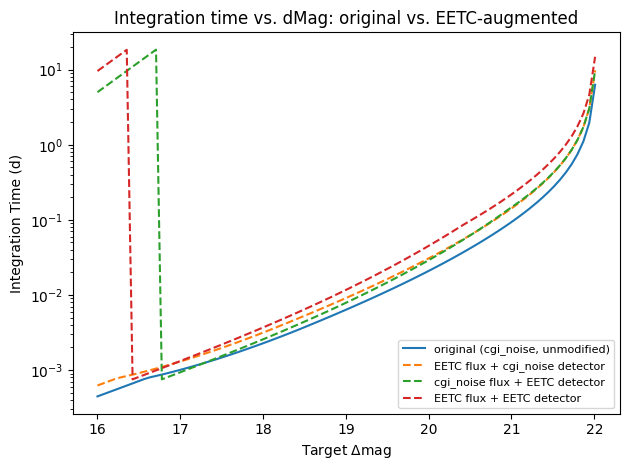

In [4]:
dMags = np.linspace(16, 23, 100)

plt.figure()

intTimes_orig = OS.calc_intTime(
    TL, [sInds] * len(dMags), fZ, JEZ, dMags, WA, mode, TK=TK
)
plt.semilogy(dMags, intTimes_orig, label="original (cgi_noise, unmodified)")

for fluxModel, detectorModel, label in EETC_COMBOS:
    intTimes = OS.calc_intTime_eetc(
        TL,
        [sInds] * len(dMags),
        fZ,
        JEZ,
        dMags,
        WA,
        mode,
        TK=TK,
        fluxModel=fluxModel,
        detectorModel=detectorModel,
    )
    plt.semilogy(dMags, intTimes, "--", label=label)

plt.xlabel(r"Target $\Delta$mag")
plt.ylabel("Integration Time (d)")
plt.title("Integration time vs. dMag: original vs. EETC-augmented")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Plot 2: per-target integration time vs. V mag (scatter)

A synthetic multi-star `TargetList` spanning V mag 0-10, comparing the
original calculator against the three EETC combos -- an "individual
targets" scatter plot.

D:\Roman_Space_Telescope\EXOSIMS\EXOSIMS\Prototypes\TargetList.py:381: UserWarning: binary_filter is None but filterBinaries is False. Using binary_filter value of None.
  warnings.warn(


Imported StarCatalog (prototype) from EXOSIMS.Prototypes.StarCatalog
specified pointer file exists!

Imported corgietc (named file) from D:\Roman_Space_[...]ietc\corgietc\corgietc.py
Imported Stark (implementation) from EXOSIMS.ZodiacalLight.Stark
Imported PostProcessing (prototype) from EXOSIMS.Prototypes.PostProcessing
Imported GalaxiesFaintStars (implementation) from EXOSIMS.BackgroundSources.GalaxiesFaintStars
Imported Completeness (prototype) from EXOSIMS.Prototypes.Completeness
Imported PlanetPopulation (prototype) from EXOSIMS.Prototypes.PlanetPopulation
Imported ForecasterMod (implementation) from EXOSIMS.PlanetPhysicalModel.ForecasterMod
100 targets imported from star catalog.
100 targets remain after removing those where spectral class cannot be established.
100 targets remain after removing white dwarfs and subdwarfs
100 targets remain after nan filtering.
100 targets remain after removing zero luminosity targets.
Loaded JEZ0 for mode e0801f22e5abd19dc9f9ed6a72afd219 from C:

D:\Roman_Space_Telescope\corgietc\corgietc\corgietc.py:819: UserWarning: Integration times for these targets may not be accurate: ['Prototype Star 90' 'Prototype Star 91' 'Prototype Star 92'
 'Prototype Star 93' 'Prototype Star 94' 'Prototype Star 95'
 'Prototype Star 96' 'Prototype Star 97' 'Prototype Star 98'
 'Prototype Star 99']
  warnings.warn(
D:\Roman_Space_Telescope\corgietc\corgietc\corgietc.py:819: UserWarning: Integration times for these targets may not be accurate: ['Prototype Star 90' 'Prototype Star 91' 'Prototype Star 92'
 'Prototype Star 93' 'Prototype Star 94' 'Prototype Star 95'
 'Prototype Star 96' 'Prototype Star 97' 'Prototype Star 98'
 'Prototype Star 99']
  warnings.warn(
D:\Roman_Space_Telescope\corgietc\corgietc\corgietc.py:1164: UserWarning: Integration times for these targets may not be accurate: ['Prototype Star 90' 'Prototype Star 91' 'Prototype Star 92'
 'Prototype Star 93' 'Prototype Star 94' 'Prototype Star 95'
 'Prototype Star 96' 'Prototype Star 97' 'P

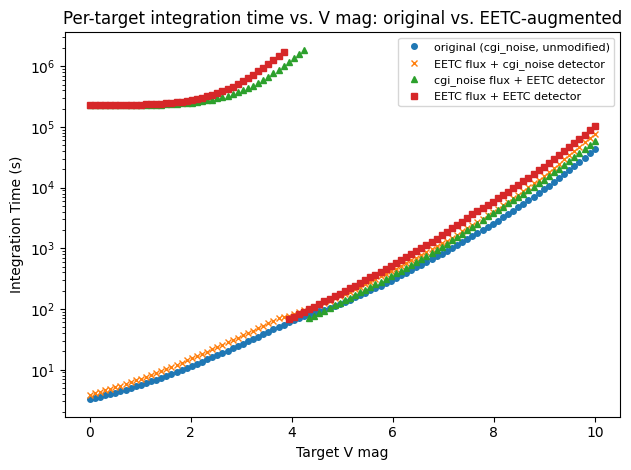

In [5]:
specs2 = copy.deepcopy(specs)
specs2["VmagFill"] = np.linspace(0, 10, 100)
specs2["ntargs"] = len(specs2["VmagFill"])
TL3 = EXOSIMS.Prototypes.TargetList.TargetList(**specs2)

sInds2 = np.arange(TL3.nStars)

plt.figure()

intTimes_v_Vmag_orig = OS.calc_intTime(
    TL3, sInds2, fZ, JEZ, dMag, WA, mode, TK=TK
).to(u.s)
plt.semilogy(
    TL3.Vmag, intTimes_v_Vmag_orig, "o", ms=4,
    label="original (cgi_noise, unmodified)",
)

markers = ["x", "^", "s"]
for (fluxModel, detectorModel, label), marker in zip(EETC_COMBOS, markers):
    intTimes_v_Vmag = OS.calc_intTime_eetc(
        TL3,
        sInds2,
        fZ,
        JEZ,
        dMag,
        WA,
        mode,
        TK=TK,
        fluxModel=fluxModel,
        detectorModel=detectorModel,
    ).to(u.s)
    plt.semilogy(TL3.Vmag, intTimes_v_Vmag, marker, ms=4, label=label)

plt.xlabel("Target V mag")
plt.ylabel("Integration Time (s)")
plt.title("Per-target integration time vs. V mag: original vs. EETC-augmented")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()